Shape of Dataset: (500, 6)

First Five Rows:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Data successfully scaled.


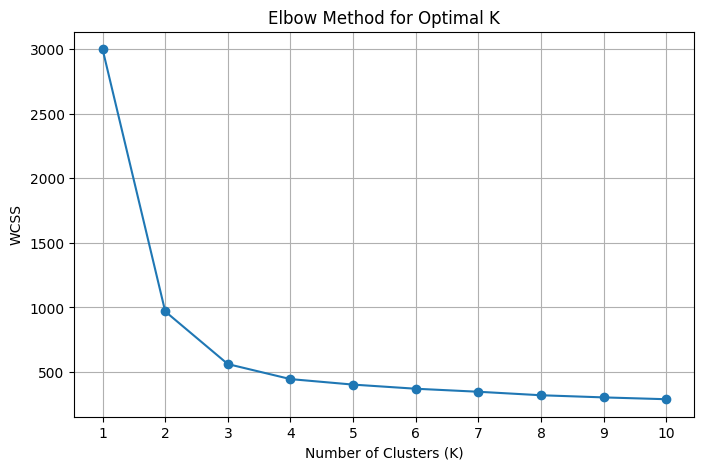


Dataset with Cluster Labels:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  cluster  
0                         6        2  
1                         3        0  
2                         4        2  
3                         2        0  
4                         1        0  

Cluster Centroids:
         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  57.037500  89814.075000          2.462500  5296.362500   
2  40.387879  43340.733333          8.193939  2021.684848   
3  

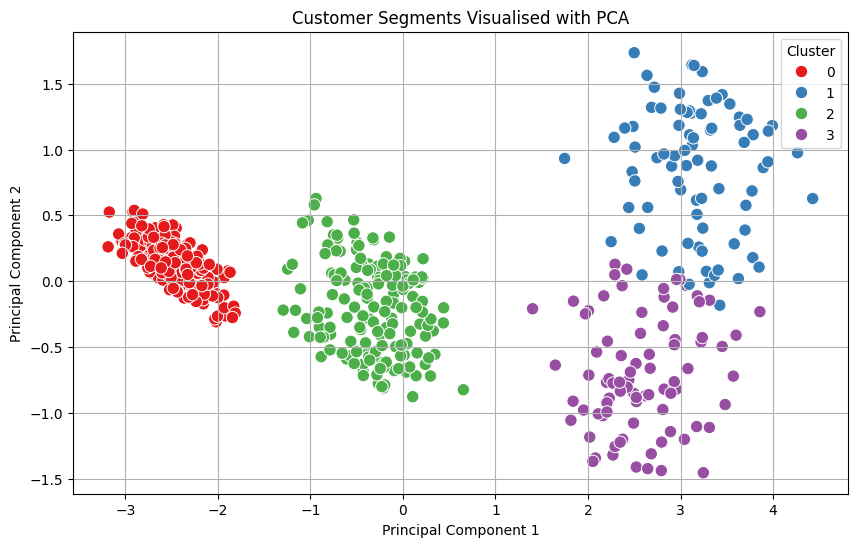

In [1]:

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Data Preparation

df = pd.read_csv("../data/q2_customers.csv")

print("Shape of Dataset:", df.shape)
print("\nFirst Five Rows:")
print(df.head())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("\nData successfully scaled.")


# 2. Choosing K — Elbow Method

wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1,11))
plt.grid(True)
plt.show()


# 3. K-Means Clustering

optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

print("\nDataset with Cluster Labels:")
print(df.head())

centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

print("\nCluster Centroids:")
print(centroids)

# 4. PCA Dimensionality Reduction

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df["PC1"] = pca_result[:, 0]
df["PC2"] = pca_result[:, 1]

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=df.columns[:-3]
)

print("\nFeature Loadings:")
print(loadings)

# 5. Cluster Visualisation

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1",
    s=80
)

plt.title("Customer Segments Visualised with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()